In [ ]:
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd
import ast
from shapely.geometry import LineString
import csv
from matplotlib.colors import to_rgb, to_hex
from pprint import pprint
import matplotlib.pyplot as plt

import pyproj
# mappymatch imports
from mappymatch.constructs.trace import Trace
from mappymatch.maps.nx.nx_map import NxMap
from mappymatch.matchers.lcss.lcss import LCSSMatcher
pd.set_option('future.no_silent_downcasting', True)

# Ploting results of map matching
### Creating graph


In [2]:
# Define your bounding box manually
north = 41.188771290159195
south = 41.13090363866696
west  = -8.699966476287791
east  = -8.559738123284369


bbox = (west, south, east, north)
# Fetch network from the bounding box
G_bbox = ox.graph_from_bbox(
    bbox=bbox,
    network_type="drive",   # can be 'drive', 'walk', etc.
    simplify=True,
)

# Project to local CRS (UTM Zone 29N, or Mercator 3857)
porto_crs = 3857
G = ox.project_graph(G_bbox, to_crs=porto_crs)

# Add geometry to edges that don't have it
for u, v, k, data in G.edges(keys=True, data=True):
    if 'geometry' not in data:
        point_u = (G.nodes[u]['x'], G.nodes[u]['y']) # x is long, y is lat
        point_v = (G.nodes[v]['x'], G.nodes[v]['y'])
        data['geometry'] = LineString([point_u, point_v])
        

### Loaindg first 15 trajectories and routes


    


In [3]:
"""" Loading the first 15 trajectories """

traj_df = pd.read_csv("train_15.csv", index_col=0)

polylines = traj_df["POLYLINE"].to_numpy()
trajectories = []

for line in polylines:
    traj = ast.literal_eval(line)  # list of (lon, lat)
    trajectories.append(traj)


# Unclean trips, used for plotting
trips = [  gpd.GeoDataFrame(
        geometry=[Point(lon, lat) for lon, lat in traj],crs="EPSG:4326"  # convert from lat/long
        ).to_crs(porto_crs) 
    for traj in trajectories]


""" Loading first 15 mapped routes """
file_name = "part_3_routes_path.csv" 

routes = []

with open(file_name, newline="") as f:
    reader = csv.reader(f)
    next(reader)  # skip header if it exists

    count = 0
    for row in reader:
        if count == 15:break
        # Convert each string tuple to actual tuple using ast.literal_eval
        route_tuples = [ast.literal_eval(tup_str) for tup_str in row]
        routes.append(route_tuples)
        count += 1

print(f"Loaded {len(routes)} routes")


# Quick reference dict: (u,v,key) -> data
edge_data_dict = {
    (u, v, k): data
    for u, v, k, data in G.edges(keys=True, data=True)
}


""" get the geometry of routes """

routes_edges = []

for route in routes:
    x_coords = []
    y_coords = []
    for tup in route:
        geom = edge_data_dict[tup]['geometry']
        x, y = geom.xy
        x_coords.extend(x)  # flatten
        y_coords.extend(y)
    routes_edges.append([x_coords, y_coords])

pprint(routes_edges[0])


Loaded 15 routes
[[-959288.3870885408,
  -959380.6375505611,
  -959389.9215960933,
  -959430.8983006544,
  -959445.9709597077,
  -959554.3627478933,
  -959554.3627478933,
  -959583.5061905829,
  -959599.8144959841,
  -959613.5958489443,
  -959679.519251392,
  -959695.7607650987,
  -959716.9114683494,
  -959722.4997067873,
  -959755.3946163167,
  -959762.1851052552,
  -959801.5254133015,
  -959851.7972953437,
  -959853.1665250805,
  -959854.4466992244,
  -959858.576652333,
  -959925.7579650268,
  -959961.3913340296,
  -959970.7533032055,
  -959970.7533032055,
  -960054.621407569,
  -960104.6261228333,
  -960141.0053324247,
  -960176.3158749043,
  -960311.6024520654,
  -960317.0459751651,
  -960323.7808043582,
  -960326.1630414611,
  -960326.1630414611,
  -960341.9704091537,
  -960357.3658947303,
  -960375.2326730026,
  -960391.2404157788,
  -960408.8956870186,
  -960428.8441397689,
  -960451.2527532654,
  -960469.3310385701,
  -960488.3332756486,
  -960513.5916681098,
  -960539.01703980

### Plotting the raw gps points and the matched route on one graph

In [4]:
# Vivid colors for trips and routes
vivid_colors = [
    "#e41a1c",  # red
    "#377eb8",  # blue
    "#4daf4a",  # green
    "#984ea3",  # purple
    "#ff7f00",  # orange
    "#ffff33",  # yellow
    "#a65628",  # brown
    "#f781bf",  # pink
    "#999999",  # gray
    "#66c2a5",  # teal
    "#fc8d62",  # salmon
    "#8da0cb",  # light blue
    "#000000",  # black
    "#a6d854",  # lime
    "#ffd92f"   # gold
]

In [5]:

def lighten_color(color, factor=0.6):
    """Lighten a color by a given factor (0=white, 1=original)."""
    rgb = to_rgb(color)
    light_rgb = [1 - factor*(1-c) for c in rgb]
    return to_hex(light_rgb)
batches = [
    [5,2],
    [1,3,10],
    [8,11,14],
    [12,9,13],
    [6,15,7,4]
]

    
for batch in batches:
    fig, ax = ox.plot_graph(
        G,
        figsize=(15,9),
        bgcolor="white",
        node_size=6,
        node_color="lightgray",
        node_zorder=1,
        edge_color="lightgray",
        edge_linewidth=3,
        show=False,
        close=False,
    )
    
    batch_str = "-".join(str(b) for b in batch)
    
    # Collect all points for this batch to compute bounding box
    all_x, all_y = [], []
    
    for index in batch:
        index -= 1
        # Base color
        base_color = vivid_colors[index]
        # Slightly lighter for trip
        trip_color = lighten_color(base_color, factor=0.5)
        
        # Plot route (solid, thick) using routes_edges
        x, y = routes_edges[index]
        ax.plot(x, y, color=base_color, linewidth=2, alpha=0.8, zorder=4, label=f"Route {index+1}")
        all_x.extend(x)
        all_y.extend(y)
        
        # Plot trip (dashed, thinner, with markers)
        x_trip, y_trip = trips[index].geometry.x, trips[index].geometry.y
        ax.plot(
            x_trip, y_trip, color=trip_color, linestyle="--", linewidth=1,
            marker="o", markersize=4, markeredgecolor="black", markeredgewidth=0.3,
            alpha=0.9, zorder=5, label=f"Trip {index+1}"
        )
        all_x.extend(x_trip)
        all_y.extend(y_trip)
    
    # Compute bounding box with small padding (5%)
    pad_x = (max(all_x) - min(all_x)) * 0.05
    pad_y = (max(all_y) - min(all_y)) * 0.05
    ax.set_xlim(min(all_x) - pad_x, max(all_x) + pad_x)
    ax.set_ylim(min(all_y) - pad_y, max(all_y) + pad_y)
    
    ax.set_title(f"Trips & Routes {batch_str}", fontsize=14, y=0.95)
    ax.legend(loc="upper right", fontsize=8, frameon=True, facecolor="white", edgecolor="black")
    
    # Save figure
    fig.savefig(f"LCSS_Images/matched_route_{batch_str}_part_4.png", dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close(fig)


### Adding edge that does not exist to trip 10

Nearest nodes: 1771990365 2352439937
No edge exists. Adding a two-way virtual link.
Two-way virtual road added successfully.


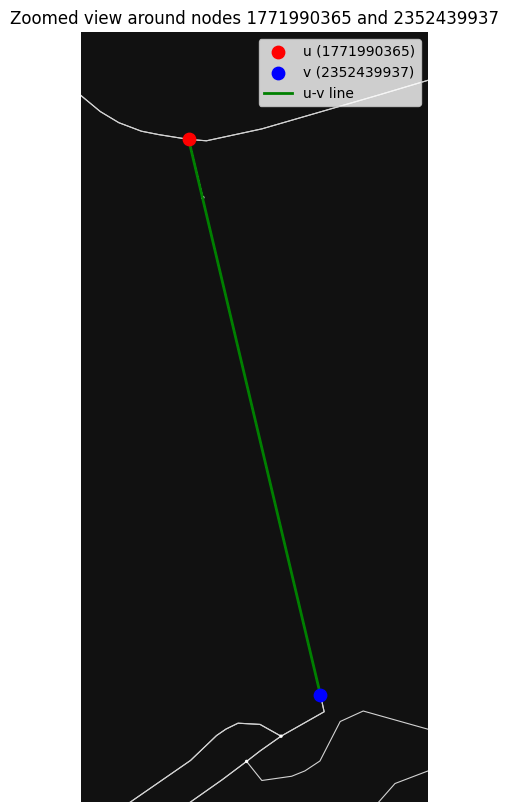

In [6]:
"""
Trip 10 uses a road link that is not part of the network, so here we add that link manually.
"""
# These points were obtained from the previous visualizing trajectory section
p1 = trajectories[9][3]
p2 = trajectories[9][4]

# Projecting lat/long to porto_crs
transformer = pyproj.Transformer.from_crs("EPSG:4326", porto_crs, always_xy=True)
x1, y1 = transformer.transform(*p1)
x2, y2 = transformer.transform(*p2)

# Find nearest nodes in the projected graph
u = ox.distance.nearest_nodes(G, X=x1, Y=y1)
v = ox.distance.nearest_nodes(G, X=x2, Y=y2)

print("Nearest nodes:", u, v)

# Check and add virtual edge if missing
if G.has_edge(u, v) or G.has_edge(v, u):
    print("An edge already exists between these nodes.")
else:
    print("No edge exists. Adding a two-way virtual link.")

    # Geometry for both directions
    geom_uv = LineString([(G.nodes[u]['x'], G.nodes[u]['y']),
                          (G.nodes[v]['x'], G.nodes[v]['y'])])
    geom_vu = LineString(list(geom_uv.coords)[::-1])

    # Edge length (in projected CRS)
    length = geom_uv.length

    # Edge data (two-way)
    edge_data_uv = {
        "osmid": -1,              # placeholder ID
        "highway": "virtual",
        "length": length,
        "geometry": geom_uv,
        "oneway": True,            # explicit one-way (forward)
        "two_way": True            # new marker to indicate originally two-way
    }

    edge_data_vu = {
        **edge_data_uv,
        "geometry": geom_vu,
    }

    # Add both directed edges
    G.add_edge(u, v, **edge_data_uv)
    G.add_edge(v, u, **edge_data_vu)

    print("Two-way virtual road added successfully.")



# Plot base graph (same as yours)
fig, ax = ox.plot_graph(
    G,
    figsize=(15, 10),
    node_size=6,
    node_color="white",
    node_zorder=1,
    edge_color="lightgray",
    edge_linewidth=0.8,
    show=False,
    close=False,
)

# Extract node coordinates
x_u, y_u = G.nodes[u]['x'], G.nodes[u]['y']
x_v, y_v = G.nodes[v]['x'], G.nodes[v]['y']

# Plot u (red) and v (blue)
ax.scatter([x_u], [y_u], c='red', s=80, zorder=5, label=f'u ({u})')
ax.scatter([x_v], [y_v], c='blue', s=80, zorder=5, label=f'v ({v})')

# Optional: line between them (green)
ax.plot([x_u, x_v], [y_u, y_v], c='green', lw=2, zorder=4, label='u-v line')

# Massive zoom: adjust limits to tightly focus on both points
pad = 50  # meters of padding, adjust as needed (smaller = tighter zoom)
minx, maxx = min(x_u, x_v) - pad, max(x_u, x_v) + pad
miny, maxy = min(y_u, y_v) - pad, max(y_u, y_v) + pad
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Add legend and title
ax.legend()
ax.set_title(f"Zoomed view around nodes {u} and {v}", fontsize=12)

plt.show()


### MapMatching Trip 10

In [10]:

matcher = LCSSMatcher( NxMap(G),
                      distance_epsilon  = 100,              # deafult = 50
                      similarity_cutoff  =0.9,                # default = 0.9
                      cutting_threshold=10,                 # default = 10
                      random_cuts=0,                        # default = 0
                      distance_threshold = 500)             # default = 10000, 

trip_10 = trips[9]
trace = Trace.from_geo_dataframe(trip_10, xy=False)  
match_result = matcher.match_trace(trace)
route_10 = [ route for route in match_result.path]

route_edge_10 = [[], []]  # [x_coords, y_coords]
for link in route_10:
    x, y = link.geom.xy
    route_edge_10[0].extend(x)
    route_edge_10[1].extend(y)

routes_edges[9] = route_edge_10

### Plot the cleaned version

In [11]:
fig, ax = ox.plot_graph(
    G,
    figsize=(15,9),
    bgcolor="white",
    node_size=6,
    node_color="lightgray",
    node_zorder=1,
    edge_color="lightgray",
    edge_linewidth=3,
    show=False,
    close=False,
)

batch = [1,3,10]

batch_str = "-".join(str(b) for b in batch)

# Collect all points for this batch to compute bounding box
all_x, all_y = [], []

for index in batch:
    index -= 1
    # Base color
    base_color = vivid_colors[index]
    # Slightly lighter for trip
    trip_color = lighten_color(base_color, factor=0.5)
    
    # Plot route (solid, thick) using routes_edges
    x, y = routes_edges[index]
    ax.plot(x, y, color=base_color, linewidth=2, alpha=0.8, zorder=4, label=f"Route {index+1}")
    all_x.extend(x)
    all_y.extend(y)
    
    # Plot trip (dashed, thinner, with markers)
    x_trip, y_trip = trips[index].geometry.x, trips[index].geometry.y
    ax.plot(
        x_trip, y_trip, color=trip_color, linestyle="--", linewidth=1,
        marker="o", markersize=4, markeredgecolor="black", markeredgewidth=0.3,
        alpha=0.9, zorder=5, label=f"Trip {index+1}"
    )
    all_x.extend(x_trip)
    all_y.extend(y_trip)

# Compute bounding box with small padding (5%)
pad_x = (max(all_x) - min(all_x)) * 0.05
pad_y = (max(all_y) - min(all_y)) * 0.05
ax.set_xlim(min(all_x) - pad_x, max(all_x) + pad_x)
ax.set_ylim(min(all_y) - pad_y, max(all_y) + pad_y)

ax.set_title(f"Trips & Routes {batch_str}", fontsize=14, y=0.95)
ax.legend(loc="upper right", fontsize=8, frameon=True, facecolor="white", edgecolor="black")

# Save figure
fig.savefig(f"LCSS_Images/cleaned_matched_route_{batch_str}_part_4.png", dpi=300, bbox_inches="tight", pad_inches=0)
plt.close(fig)
